Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 2, include concepts such as linear regression with lasso, ridge, and elastic net regression. This homework will be submitted for peer review and feedback in Week 3 in the assignment titled 3.4 Peer Review: Week 2 Jupyter Notebook. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday.

In Week 7, you will compile your findings from your Jupyter Notebook homework into your Milestone One assignment for grading. For full instructions and the rubric for Milestone One, refer to the following link. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone


In [2]:
from src.load_data import load_wisconsin, load_brazil, split_X_y

df_brazil, target = load_brazil(sample_size= 50_000)
X_brazil, y_brazil = split_X_y(df_brazil, target)


In [3]:


X_brazil.info()
y_brazil

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 700187 to 754772
Data columns (total 39 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        50000 non-null  float64
 1   profession_code                            50000 non-null  float64
 2   morphology_code                            50000 non-null  int64  
 3   gender_female                              50000 non-null  int64  
 4   gender_unknown                             50000 non-null  int64  
 5   gender_male                                50000 non-null  int64  
 6   race_color_yellow                          50000 non-null  int64  
 7   race_color_white                           50000 non-null  int64  
 8   race_color_indigenous                      50000 non-null  int64  
 9   race_color_brown                           50000 non-null  int64  
 10  race_color_black     

700187     0
1473092    0
1119056    0
1614127    0
1714606    0
          ..
603780     1
278573     0
768371     0
558743     0
754772     0
Name: deceased, Length: 50000, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
import pandas as pd


X_train, X_test, y_train, y_test = train_test_split(
    X_brazil,
    y_brazil, 
    random_state=42, 
    test_size=.2, 
    stratify = y_brazil
    )

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, solver="saga", class_weight="balanced"))
])


grid_params = [
    {"model__penalty":["l2"], "model__C": [0.01, 0.1, 1, 10]},
    {"model__penalty":["l1"], "model__C": [0.01, 0.1, 1, 10]},
    
    {
      "model__penalty":["elasticnet"], 
      "model__C": [0.01, 0.1, 1, 10],
      "model__l1_ratio": [0.2, 0.5, 0.8]
    }
    
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid= grid_params,
    cv = 5,
    scoring = "roc_auc",
    n_jobs= -1,
    verbose=1
)

grid.fit(X_train, y_train)

brazil_results = pd.DataFrame(grid.cv_results_)
brazil_best_model = grid.best_estimator_
brazil_best_params = grid.best_params_
brazil_best_cv_score = grid.best_score_



print(f"best model: {brazil_best_model}")
print(f"best params:{brazil_best_params}")
print(f"best_cv_score: {brazil_best_cv_score}")

brazil_results.head()




Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/jamieconner/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/Users/jamieconner/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/Users/jamieconner/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=3000, penalty='l1',
                                    solver='saga'))])
best params:{'model__C': 0.1, 'model__penalty': 'l1'}
best_cv_score: 0.9388488819626456


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.428484,4.024024,0.007618,0.002927,0.01,l2,NaN,"{'model__C': 0.01, 'model__penalty': 'l2'}",0.944552,0.935841,0.937182,0.936941,0.938798,0.938663,0.003092,19
1,14.611570,18.378199,0.009292,0.003388,0.10,l2,NaN,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.944554,0.936255,0.937467,0.936996,0.938826,0.938820,0.002987,6
2,20.720927,15.768454,0.007544,0.004135,1.00,l2,NaN,"{'model__C': 1, 'model__penalty': 'l2'}",0.944536,0.935713,0.937036,0.936945,0.938812,0.938608,0.003124,20
3,20.759284,0.833640,0.007773,0.002272,10.00,l2,NaN,"{'model__C': 10, 'model__penalty': 'l2'}",0.944569,0.936334,0.937465,0.936939,0.938811,0.938824,0.002987,4
4,10.039545,8.921824,0.007294,0.001263,0.01,l1,NaN,"{'model__C': 0.01, 'model__penalty': 'l1'}",0.944875,0.935890,0.937314,0.936531,0.939022,0.938726,0.003248,14


In [5]:
brazil_results.sort_values("rank_test_score")


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,13.431524,6.788430,0.007157,0.002049,0.10,l1,NaN,"{'model__C': 0.1, 'model__penalty': 'l1'}",0.944571,0.936323,0.937559,0.936885,0.938907,0.938849,0.002988,1
11,8.726645,3.869772,0.006425,0.002182,0.10,elasticnet,0.2,"{'model__C': 0.1, 'model__l1_ratio': 0.2, 'mod...",0.944568,0.936302,0.937495,0.936977,0.938861,0.938841,0.002984,2
13,16.550482,15.370527,0.004723,0.000760,0.10,elasticnet,0.8,"{'model__C': 0.1, 'model__l1_ratio': 0.8, 'mod...",0.944592,0.936214,0.937558,0.936915,0.938903,0.938836,0.003011,3
3,20.759284,0.833640,0.007773,0.002272,10.00,l2,NaN,"{'model__C': 10, 'model__penalty': 'l2'}",0.944569,0.936334,0.937465,0.936939,0.938811,0.938824,0.002987,4
12,15.825346,14.804802,0.005554,0.002202,0.10,elasticnet,0.5,"{'model__C': 0.1, 'model__l1_ratio': 0.5, 'mod...",0.944568,0.936222,0.937496,0.936953,0.938878,0.938823,0.003001,5
1,14.611570,18.378199,0.009292,0.003388,0.10,l2,NaN,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.944554,0.936255,0.937467,0.936996,0.938826,0.938820,0.002987,6
16,24.300037,10.048744,0.004660,0.001855,1.00,elasticnet,0.8,"{'model__C': 1, 'model__l1_ratio': 0.8, 'model...",0.944565,0.936161,0.937463,0.936935,0.938808,0.938786,0.003016,7
17,29.372587,10.165943,0.004265,0.001457,10.00,elasticnet,0.2,"{'model__C': 10, 'model__l1_ratio': 0.2, 'mode...",0.944513,0.936184,0.937513,0.936940,0.938728,0.938775,0.002986,8
10,6.158494,3.669926,0.004756,0.001293,0.01,elasticnet,0.8,"{'model__C': 0.01, 'model__l1_ratio': 0.8, 'mo...",0.944843,0.935872,0.937325,0.936619,0.939197,0.938771,0.003230,9
9,4.084306,2.572562,0.008406,0.005240,0.01,elasticnet,0.5,"{'model__C': 0.01, 'model__l1_ratio': 0.5, 'mo...",0.944726,0.935832,0.937340,0.936726,0.939180,0.938761,0.003178,10


For Week 2, I compared ridge, lasso, and elastic net regularized logistic regression on the Brazil dataset using cross-validated ROC-AUC as the primary metric. Because the dataset contains over 1.7 million rows, I used a random sample to keep the grid search computationally manageable. I also used a stratified train/test split because the target variable was imbalanced. The best cross-validated model was lasso logistic regression with C = 0.1, which indicates relatively strong regularization and suggests that a sparser model generalized slightly better than the alternatives.

However, the performance differences across ridge, lasso, and elastic net were small, with mean CV scores within roughly a couple thousandths of one another. This suggests that the choice of regularization type did not dramatically change predictive performance on this dataset. Even so, lasso was still the most useful result because it provided the best CV score while also encouraging a simpler model through coefficient shrinkage and feature selection. I also tested class_weight="balanced" because of the class imbalance, but it did not materially improve ROC-AUC, suggesting that class weighting was not a major driver of performance for this particular modeling objective. 

In [6]:
df_wisc, target = load_wisconsin()
X_wisc, y_wisc = split_X_y(df_wisc, target)

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X_wisc,
    y_wisc, 
    random_state=42, 
    test_size=.2, 
    stratify = y_wisc
    )

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10_000, solver="saga"))
])


grid_params = [
    {"model__penalty":["l2"], "model__C": [0.01, 0.1, 1, 10]},
    {"model__penalty":["l1"], "model__C": [0.01, 0.1, 1, 10]},
    
    {
      "model__penalty":["elasticnet"], 
      "model__C": [0.01, 0.1, 1, 10],
      "model__l1_ratio": [0.2, 0.5, 0.8]
    }
    
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid= grid_params,
    cv = 5,
    scoring = "roc_auc",
    n_jobs= -1,
    verbose=1
)

grid.fit(X_train, y_train)

wisc_results = pd.DataFrame(grid.cv_results_)
wisc_best_model = grid.best_estimator_
wisc_best_params = grid.best_params_
wisc_best_cv_score = grid.best_score_



print(f"best model: {wisc_best_model}")
print(f"best params:{wisc_best_params}")
print(f"best_cv_score: {wisc_best_cv_score}")

sorted_results = wisc_results.sort_values("rank_test_score")
sorted_results



Fitting 5 folds for each of 20 candidates, totalling 100 fits


best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=10, max_iter=10000, solver='saga'))])
best params:{'model__C': 10, 'model__penalty': 'l2'}
best_cv_score: 0.9959752321981424


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.129512,0.009818,0.002109,0.001094,10.00,l2,NaN,"{'model__C': 10, 'model__penalty': 'l2'}",0.997936,1.000000,0.987616,1.000000,0.994324,0.995975,0.004666,1
19,0.284124,0.035335,0.001179,0.000035,10.00,elasticnet,0.8,"{'model__C': 10, 'model__l1_ratio': 0.8, 'mode...",0.997936,1.000000,0.987616,1.000000,0.993808,0.995872,0.004707,2
17,0.229983,0.012485,0.002276,0.001408,10.00,elasticnet,0.2,"{'model__C': 10, 'model__l1_ratio': 0.2, 'mode...",0.997936,1.000000,0.987616,1.000000,0.993808,0.995872,0.004707,2
18,0.278621,0.037073,0.001482,0.000544,10.00,elasticnet,0.5,"{'model__C': 10, 'model__l1_ratio': 0.5, 'mode...",0.997420,1.000000,0.987616,1.000000,0.993808,0.995769,0.004666,4
7,0.411824,0.043732,0.001258,0.000051,10.00,l1,NaN,"{'model__C': 10, 'model__penalty': 'l1'}",0.997420,1.000000,0.987100,1.000000,0.994324,0.995769,0.004812,5
2,0.030668,0.003581,0.001732,0.000859,1.00,l2,NaN,"{'model__C': 1, 'model__penalty': 'l2'}",0.998452,1.000000,0.984004,0.998968,0.994324,0.995150,0.005898,6
14,0.061324,0.002887,0.002345,0.001136,1.00,elasticnet,0.2,"{'model__C': 1, 'model__l1_ratio': 0.2, 'model...",0.998452,1.000000,0.984004,0.998968,0.994324,0.995150,0.005898,6
6,0.283193,0.103907,0.001753,0.000913,1.00,l1,NaN,"{'model__C': 1, 'model__penalty': 'l1'}",0.998452,1.000000,0.984004,0.998452,0.993292,0.994840,0.005874,8
16,0.139426,0.028754,0.001840,0.000968,1.00,elasticnet,0.8,"{'model__C': 1, 'model__l1_ratio': 0.8, 'model...",0.998452,1.000000,0.982972,0.998452,0.993808,0.994737,0.006238,9
15,0.082939,0.008379,0.001653,0.000594,1.00,elasticnet,0.5,"{'model__C': 1, 'model__l1_ratio': 0.5, 'model...",0.998452,1.000000,0.982456,0.998968,0.993808,0.994737,0.006497,10


Compared with the unregularized or baseline logistic model from Week 1, regularized logistic regression produced very similar performance. The best Week 2 model used L2 regularization with C=10, but several L1 and elastic net models had nearly identical cross-validation scores. This suggests that the Wisconsin data are already clean and strongly separable, so regularization mainly provides stability rather than a major performance improvement. The main value of regularization here is not boosting accuracy, but controlling coefficient size and reducing risk from correlated tumor-measurement features.

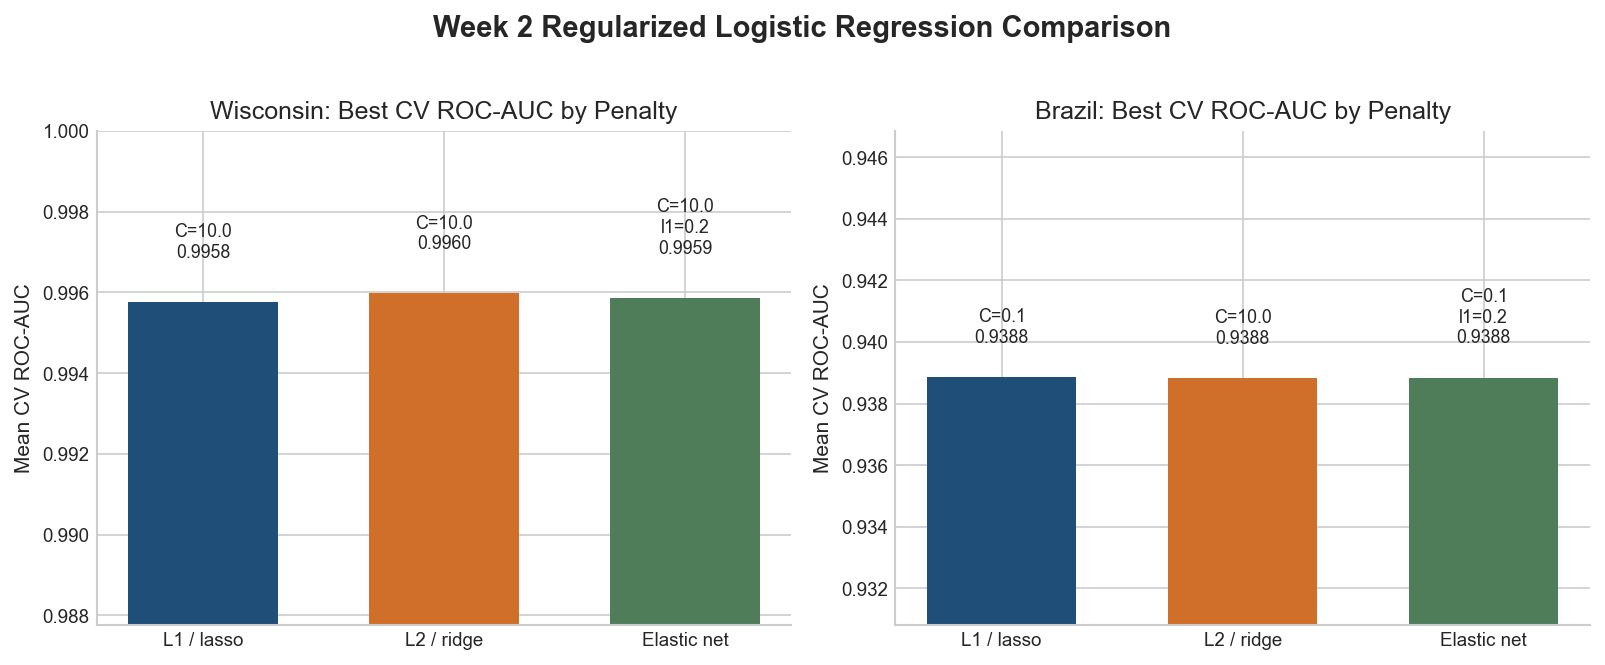

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def summarize_regularization_results(results_df):
    summary = results_df.copy()
    summary["penalty_family"] = summary["param_model__penalty"].astype(str)
    summary["penalty_label"] = summary["penalty_family"].map({
        "l1": "L1 / lasso",
        "l2": "L2 / ridge",
        "elasticnet": "Elastic net",
    })
    best_by_penalty = (
        summary.sort_values(["penalty_family", "mean_test_score"], ascending=[True, False])
        .groupby("penalty_family", as_index=False)
        .first()
    )
    return best_by_penalty[["penalty_family", "penalty_label", "param_model__C", "param_model__l1_ratio", "mean_test_score"]]

brazil_plot_df = summarize_regularization_results(brazil_results)
wisc_plot_df = summarize_regularization_results(wisc_results)
order = ["l1", "l2", "elasticnet"]
plot_frames = [
    ("Wisconsin", wisc_plot_df.set_index("penalty_family").loc[order].reset_index()),
    ("Brazil", brazil_plot_df.set_index("penalty_family").loc[order].reset_index()),
]
colors = ["#1F4E79", "#D06F2A", "#4F7D5A"]

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3), sharey=False)
for ax, (dataset_name, plot_df) in zip(axes, plot_frames):
    bars = ax.bar(plot_df["penalty_label"], plot_df["mean_test_score"], color=colors, width=0.62)
    ax.set_title(f"{dataset_name}: Best CV ROC-AUC by Penalty")
    ax.set_ylabel("Mean CV ROC-AUC")
    y_min = max(0, plot_df["mean_test_score"].min() - 0.008)
    y_max = min(1.0, plot_df["mean_test_score"].max() + 0.008)
    ax.set_ylim(y_min, y_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        ratio = row["param_model__l1_ratio"]
        ratio_text = "" if ratio != ratio else f"\nl1={ratio}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            row["mean_test_score"] + 0.001,
            f"C={row['param_model__C']}{ratio_text}\n{row['mean_test_score']:.4f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

fig.suptitle("Week 2 Regularized Logistic Regression Comparison", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig02_regularization_cv_roc_auc.png", bbox_inches="tight", facecolor="white")
plt.show()
